## Nested Cross-Validation mit Feature-Selektion, Hyperparameter-Tuning und Kalibrierung

Dieses Skript implementiert einen robusten Workflow zur Entwicklung eines **logistischen Regressionsmodells** mit integrierter **Feature-Selektion**, **Hyperparameter-Optimierung** und **Wahrscheinlichkeitskalibrierung**. Ziel ist es, die Modellleistung möglichst realistisch und ohne Data Leakage zu bewerten.

### Ablauf

1. Die Excel-Datei wird eingelesen, die Zielvariable getrennt und auf numerische Features beschränkt.
2. Innerhalb jedes Outer-Folds werden die Features zunächst über **Mutual Information** gerankt und anschließend mit einem **Korrelationsfilter** bereinigt, um redundante Variablen zu reduzieren.
3. Im inneren Cross-Validation-Schritt optimiert **Optuna** zwei zentrale Parameter:
   - die Anzahl der zu verwendenden Features
   - die Regularisierungsstärke `C` der logistischen Regression
4. Mit den besten Parametern wird im jeweiligen Outer-Fold ein finales Modell trainiert.
5. Die vorhergesagten Wahrscheinlichkeiten werden zusätzlich mit **Platt Scaling** (`sigmoid`) kalibriert.
6. Abschließend werden die Leistungen über alle Outer-Folds hinweg zusammengefasst.

### Zentrale Bestandteile

- **Nested Cross-Validation** trennt Optimierung und Testbewertung sauber
- **Mutual Information + Korrelationsfilter** reduziert das Feature-Set datengetrieben
- **Optuna** sucht robuste Hyperparameter innerhalb der Trainingsdaten
- **Kalibrierung** verbessert die Interpretierbarkeit der Modellwahrscheinlichkeiten

### Ausgabe und Nutzen

Das Skript liefert:
- Leistungsmetriken mit empirischen Konfidenzintervallen
- eine Zusammenfassung der gewählten Hyperparameter
- die am häufigsten ausgewählten Features
- gepoolte ROC- und Kalibrationsplots über alle Outer-Testfolds

Damit eignet sich der Workflow besonders für eine methodisch saubere Modellentwicklung bei kleinen bis mittleren Datensätzen, in denen sowohl **Feature-Stabilität** als auch **realistische Generalisierbarkeit** wichtig sind.

Outer fold 1/50
Outer fold 2/50
Outer fold 3/50
Outer fold 4/50
Outer fold 5/50
Outer fold 6/50
Outer fold 7/50
Outer fold 8/50
Outer fold 9/50
Outer fold 10/50
Outer fold 11/50
Outer fold 12/50
Outer fold 13/50
Outer fold 14/50
Outer fold 15/50
Outer fold 16/50
Outer fold 17/50
Outer fold 18/50
Outer fold 19/50
Outer fold 20/50
Outer fold 21/50
Outer fold 22/50
Outer fold 23/50
Outer fold 24/50
Outer fold 25/50
Outer fold 26/50
Outer fold 27/50
Outer fold 28/50
Outer fold 29/50
Outer fold 30/50
Outer fold 31/50
Outer fold 32/50
Outer fold 33/50
Outer fold 34/50
Outer fold 35/50
Outer fold 36/50
Outer fold 37/50
Outer fold 38/50
Outer fold 39/50
Outer fold 40/50
Outer fold 41/50
Outer fold 42/50
Outer fold 43/50
Outer fold 44/50
Outer fold 45/50
Outer fold 46/50
Outer fold 47/50
Outer fold 48/50
Outer fold 49/50
Outer fold 50/50

PAPER-STYLE PERFORMANCE SUMMARY


,Metric,Result
0,Train Accuracy,0.963 (0.892–1.000)
1,Test Accuracy,0.860 (0.747–1.000)
2,Balanced Accuracy,0.861 (0.744–1.000)
3,F1,0.866 (0.740–1.000)
4,Recall,0.847 (0.602–1.000)
5,Precision,0.900 (0.750–1.000)
6,ROC-AUC,0.948 (0.838–1.000)
7,PR-AUC,0.960 (0.856–1.000)
8,Brier,0.104 (0.057–0.166)
9,LogLoss,0.346 (0.228–0.518)



HYPERPARAMETER SUMMARY


,Parameter,Result
0,C,0.842 (0.054–4.722)
1,Num Features,37.1 (12.9–50.0)



TOP 38 MOST FREQUENTLY SELECTED FEATURES (OPTIMAL COUNT)


,Feature,Selection Count,Selection Frequency (%)
16,CMJ_KAI ecc,49,98.0
4,CMJ_KAI con,49,98.0
2,INV_ISO_Arbeit_Unterschied Extension Flexion,48,96.0
5,UNINV_ISO_Max Flexion,48,96.0
19,INV_ISO_Drehmoment_Unterschied Extension Flexion,46,92.0
6,UNINV_CMJ_uni_Relative Peak Landing Force-Mitt...,45,90.0
11,INV_CMJ_uni_Max Rate of Force Development-Mitt...,44,88.0
15,INV_ISO_Drehmoment_Verhaeltnis Flexion Extension,42,84.0
20,INV_Arbeit_Flexion,41,82.0
13,UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s],41,82.0



POOLED OUTER-FOLD METRICS


,Metric,Value
0,Pooled ROC-AUC,0.943
1,Pooled PR-AUC,0.951
2,Pooled Brier,0.105
3,Pooled LogLoss,0.347


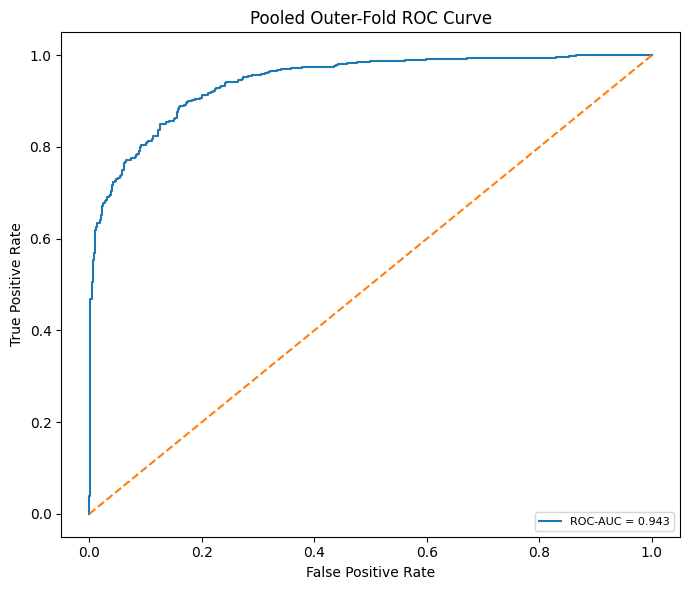

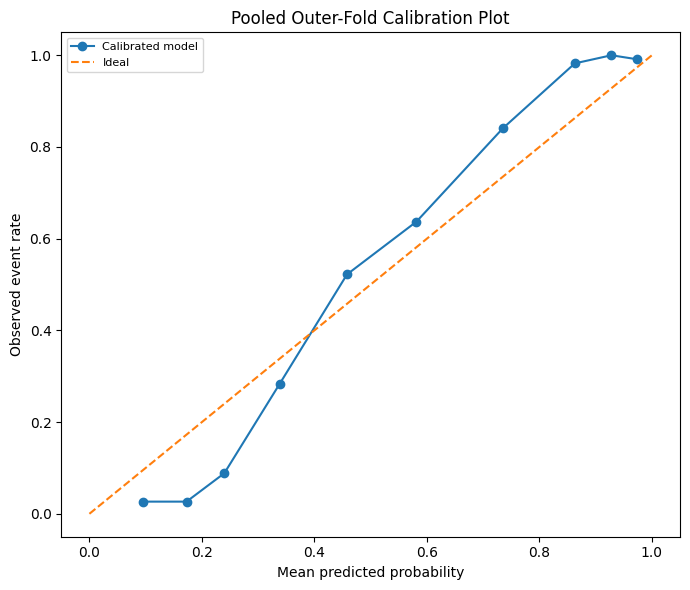

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# =============================================================================
# KONFIGURATION
# =============================================================================
FILE_PATH = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Basistabelle_ML_neu.xlsx"
TARGET_COL = "Verletzungsstatus"
UNSCALED_COLS = ["Geschlecht_weiblich"]   # bleibt unskaliert
POS_LABEL = 1

OUTER_N_SPLITS = 5
OUTER_N_REPEATS = 10
INNER_N_SPLITS = 5

RANDOM_STATE = 42
CORR_THRESHOLD = 0.80

OPTUNA_TRIALS = 25
NUM_FEATURES_MIN = 10
NUM_FEATURES_MAX = 50
C_MIN = 0.05
C_MAX = 5.0

CALIBRATION_METHOD = "sigmoid"  # Platt scaling
LOGREG_SOLVER = "liblinear"
LOGREG_PENALTY = "l2"
LOGREG_MAX_ITER = 1000


# =============================================================================
# DATEN LADEN
# =============================================================================
def load_data(file_path: str, target_col: str):
    df = pd.read_excel(file_path)

    if target_col not in df.columns:
        raise ValueError(f"Zielspalte '{target_col}' nicht in Datei gefunden.")

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    # nur numerische Features
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        print(f"Hinweis: Nicht-numerische Spalten werden entfernt: {non_numeric}")
        X = X.select_dtypes(include=[np.number]).copy()

    return X, y


# =============================================================================
# SKALIERUNG OHNE LEAKAGE
# =============================================================================
def get_scale_columns(X: pd.DataFrame, unscaled_cols: list):
    return [c for c in X.columns if c not in unscaled_cols]


def scale_train_test(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    unscaled_cols: list
):
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    cols_to_scale = get_scale_columns(X_train, unscaled_cols)
    scaler = StandardScaler()

    if len(cols_to_scale) > 0:
        X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

    return X_train_scaled, X_test_scaled, scaler


# =============================================================================
# FEATURE RANKING: MUTUAL INFORMATION + KORRELATIONSFILTER
# =============================================================================
def rank_features_mi_corr(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    correlation_threshold: float = 0.80,
    random_state: int = 42
):
    """
    1) Mutual Information pro Feature berechnen
    2) Features nach MI absteigend sortieren
    3) Korrelierte Features konservativ filtern:
       ein Feature wird nur behalten, wenn es zu bereits behaltenen Features
       keine absolute Korrelation > threshold hat
    """

    X_train = X_train.copy()

    # MI berechnen
    mi = mutual_info_classif(X_train, y_train, random_state=random_state)
    mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

    # Korrelationen
    corr_matrix = X_train.corr().abs()

    selected = []
    for feat in mi_series.index:
        if len(selected) == 0:
            selected.append(feat)
            continue

        max_corr = corr_matrix.loc[feat, selected].max()
        if pd.isna(max_corr) or max_corr <= correlation_threshold:
            selected.append(feat)

    return selected, mi_series


# =============================================================================
# MODELL / KALIBRIERUNG
# =============================================================================
def make_base_model(C_value: float):
    return LogisticRegression(
        C=C_value,
        penalty=LOGREG_PENALTY,
        solver=LOGREG_SOLVER,
        max_iter=LOGREG_MAX_ITER,
        random_state=RANDOM_STATE
    )


def make_calibrated_model(base_model, method="sigmoid", cv=5):
    """
    Kompatibel mit älteren und neueren sklearn-Versionen.
    """
    try:
        model = CalibratedClassifierCV(
            estimator=base_model,
            method=method,
            cv=cv
        )
    except TypeError:
        model = CalibratedClassifierCV(
            base_estimator=base_model,
            method=method,
            cv=cv
        )
    return model


# =============================================================================
# INNER SCORE FÜR OPTUNA
# =============================================================================
def evaluate_inner_params(
    X_train_outer: pd.DataFrame,
    y_train_outer: pd.Series,
    num_features: int,
    C_value: float,
    correlation_threshold: float = 0.80,
    inner_n_splits: int = 5,
    random_state: int = 42,
    unscaled_cols: list = None
):
    """
    Für einen Satz Hyperparameter:
    - innerhalb des Outer-Train-Folds erneut CV
    - in JEDEM inneren Trainingsfold:
        * MI + Korrelationsfilter
        * Top-k Features
        * Skalierung nur auf inner_train
        * Logistic Regression
        * ROC-AUC auf inner_val
    """
    if unscaled_cols is None:
        unscaled_cols = []

    inner_cv = StratifiedKFold(
        n_splits=inner_n_splits,
        shuffle=True,
        random_state=random_state
    )

    inner_scores = []

    for inner_train_idx, inner_val_idx in inner_cv.split(X_train_outer, y_train_outer):
        X_inner_train = X_train_outer.iloc[inner_train_idx].copy()
        X_inner_val = X_train_outer.iloc[inner_val_idx].copy()
        y_inner_train = y_train_outer.iloc[inner_train_idx].copy()
        y_inner_val = y_train_outer.iloc[inner_val_idx].copy()

        ranked_features, _ = rank_features_mi_corr(
            X_inner_train,
            y_inner_train,
            correlation_threshold=correlation_threshold,
            random_state=random_state
        )

        if len(ranked_features) == 0:
            ranked_features = list(X_inner_train.columns)

        k = min(num_features, len(ranked_features))
        selected_features = ranked_features[:k]

        X_inner_train_sel = X_inner_train[selected_features].copy()
        X_inner_val_sel = X_inner_val[selected_features].copy()

        X_inner_train_sel, X_inner_val_sel, _ = scale_train_test(
            X_inner_train_sel,
            X_inner_val_sel,
            unscaled_cols=unscaled_cols
        )

        model = make_base_model(C_value=C_value)
        model.fit(X_inner_train_sel, y_inner_train)

        y_inner_val_proba = model.predict_proba(X_inner_val_sel)[:, 1]
        score = roc_auc_score(y_inner_val, y_inner_val_proba)
        inner_scores.append(score)

    return float(np.mean(inner_scores))


def optimize_inner_fold(
    X_train_outer: pd.DataFrame,
    y_train_outer: pd.Series,
    n_trials: int = 25,
    correlation_threshold: float = 0.80,
    num_features_min: int = 10,
    num_features_max: int = 50,
    c_min: float = 0.05,
    c_max: float = 5.0,
    inner_n_splits: int = 5,
    random_state: int = 42,
    unscaled_cols: list = None
):
    if unscaled_cols is None:
        unscaled_cols = []

    # Kandidatenpool im aktuellen Outer-Train-Fold bestimmen,
    # um realistische obere Grenze für num_features zu haben.
    ranked_outer, _ = rank_features_mi_corr(
        X_train_outer,
        y_train_outer,
        correlation_threshold=correlation_threshold,
        random_state=random_state
    )
    n_candidates = len(ranked_outer)

    if n_candidates == 0:
        n_candidates = X_train_outer.shape[1]

    effective_min = min(num_features_min, n_candidates)
    effective_max = min(num_features_max, n_candidates)

    if effective_min > effective_max:
        effective_min = 1
        effective_max = n_candidates

    def objective(trial):
        num_features = trial.suggest_int("num_features", effective_min, effective_max)
        c_value = trial.suggest_float("C", c_min, c_max, log=True)

        score = evaluate_inner_params(
            X_train_outer=X_train_outer,
            y_train_outer=y_train_outer,
            num_features=num_features,
            C_value=c_value,
            correlation_threshold=correlation_threshold,
            inner_n_splits=inner_n_splits,
            random_state=random_state,
            unscaled_cols=unscaled_cols
        )
        return score

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, n_jobs=1)

    return study, ranked_outer


# =============================================================================
# METRIKEN / CI / FORMATIERUNG
# =============================================================================
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        "Train/Test Accuracy placeholder": np.nan,  # wird später überschrieben
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Precision": precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Brier": brier_score_loss(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba, labels=[0, 1]),
    }


def empirical_ci(values, alpha=0.05):
    values = np.asarray(values, dtype=float)
    lower = np.percentile(values, 100 * (alpha / 2))
    upper = np.percentile(values, 100 * (1 - alpha / 2))
    mean_val = np.mean(values)
    return mean_val, lower, upper


def format_ci(mean_val, low, high, decimals=3):
    return f"{mean_val:.{decimals}f} ({low:.{decimals}f}–{high:.{decimals}f})"


def summarize_metric_dict(metric_dict, decimals=3):
    rows = []
    for metric_name, values in metric_dict.items():
        mean_val, low, high = empirical_ci(values)
        rows.append({
            "Metric": metric_name,
            "Result": format_ci(mean_val, low, high, decimals=decimals)
        })
    return pd.DataFrame(rows)

def get_top_features_by_optimal_count(feature_frequency_table, fold_metrics):
    """
    Leitet die optimale Anzahl finaler Features aus der mittleren Feature-Anzahl
    der Outer-Folds ab und gibt die Top-N Features nach Selektionshäufigkeit zurück.
    Beispiel: 37.08 -> 38
    """
    mean_num_features = np.mean(fold_metrics["Num Features"])
    optimal_n = int(np.ceil(mean_num_features))

    optimal_n = max(1, min(optimal_n, len(feature_frequency_table)))

    top_feature_table = feature_frequency_table.head(optimal_n).copy()

    return optimal_n, top_feature_table

# =============================================================================
# ROC- UND KALIBRIERUNGS-PLOTS
# =============================================================================
def plot_pooled_roc(y_true_all, y_proba_all):
    fpr, tpr, _ = roc_curve(y_true_all, y_proba_all, pos_label=POS_LABEL)
    auc_value = roc_auc_score(y_true_all, y_proba_all)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Pooled Outer-Fold ROC Curve")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_pooled_calibration(y_true_all, y_proba_all, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true_all,
        y_proba_all,
        n_bins=n_bins,
        strategy="quantile"
    )

    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Calibrated model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event rate")
    plt.title("Pooled Outer-Fold Calibration Plot")
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


# =============================================================================
# HAUPTFUNKTION: NESTED CV + FEATURE SELECTION + OPTUNA + KALIBRIERUNG
# =============================================================================
def nested_cv_with_feature_selection_and_calibration(
    X: pd.DataFrame,
    y: pd.Series,
    unscaled_cols: list = None,
    outer_n_splits: int = 5,
    outer_n_repeats: int = 10,
    inner_n_splits: int = 5,
    n_trials: int = 25,
    correlation_threshold: float = 0.80,
    num_features_min: int = 10,
    num_features_max: int = 50,
    c_min: float = 0.05,
    c_max: float = 5.0,
    random_state: int = 42
):
    if unscaled_cols is None:
        unscaled_cols = []

    outer_cv = RepeatedStratifiedKFold(
        n_splits=outer_n_splits,
        n_repeats=outer_n_repeats,
        random_state=random_state
    )

    # Sammelcontainer
    fold_metrics = {
        "Train Accuracy": [],
        "Test Accuracy": [],
        "Balanced Accuracy": [],
        "F1": [],
        "Recall": [],
        "Precision": [],
        "ROC-AUC": [],
        "PR-AUC": [],
        "Brier": [],
        "LogLoss": [],
        "Num Features": [],
    }

    selected_features_all = []
    chosen_c_values = []
    fold_details = []

    y_true_all = []
    y_proba_all = []
    y_pred_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        print(f"Outer fold {fold_idx}/{outer_n_splits * outer_n_repeats}")

        X_train_outer = X.iloc[train_idx].copy()
        X_test_outer = X.iloc[test_idx].copy()
        y_train_outer = y.iloc[train_idx].copy()
        y_test_outer = y.iloc[test_idx].copy()

        # -------------------------
        # 1) Inner Optimization
        # -------------------------
        study, ranked_outer = optimize_inner_fold(
            X_train_outer=X_train_outer,
            y_train_outer=y_train_outer,
            n_trials=n_trials,
            correlation_threshold=correlation_threshold,
            num_features_min=num_features_min,
            num_features_max=num_features_max,
            c_min=c_min,
            c_max=c_max,
            inner_n_splits=inner_n_splits,
            random_state=random_state,
            unscaled_cols=unscaled_cols
        )

        best_num_features = study.best_trial.params["num_features"]
        best_C = study.best_trial.params["C"]

        if len(ranked_outer) == 0:
            ranked_outer = list(X_train_outer.columns)

        k = min(best_num_features, len(ranked_outer))
        selected_features = ranked_outer[:k]

        selected_features_all.append(selected_features)
        chosen_c_values.append(best_C)

        # -------------------------
        # 2) Outer Train/Test mit finalen Features
        # -------------------------
        X_train_sel = X_train_outer[selected_features].copy()
        X_test_sel = X_test_outer[selected_features].copy()

        X_train_sel, X_test_sel, _ = scale_train_test(
            X_train_sel,
            X_test_sel,
            unscaled_cols=unscaled_cols
        )

        # -------------------------
        # 3) Finales Modell + Kalibrierung NUR auf Outer-Train
        # -------------------------
        base_model = make_base_model(C_value=best_C)
        calibrated_model = make_calibrated_model(
            base_model=base_model,
            method=CALIBRATION_METHOD,
            cv=inner_n_splits
        )
        calibrated_model.fit(X_train_sel, y_train_outer)

        # -------------------------
        # 4) Prediction
        # -------------------------
        y_train_pred = calibrated_model.predict(X_train_sel)
        y_test_pred = calibrated_model.predict(X_test_sel)

        y_train_proba = calibrated_model.predict_proba(X_train_sel)[:, 1]
        y_test_proba = calibrated_model.predict_proba(X_test_sel)[:, 1]

        # -------------------------
        # 5) Metriken
        # -------------------------
        train_acc = accuracy_score(y_train_outer, y_train_pred)

        test_metrics = calculate_metrics(y_test_outer, y_test_pred, y_test_proba)

        fold_metrics["Train Accuracy"].append(train_acc)
        fold_metrics["Test Accuracy"].append(test_metrics["Accuracy"])
        fold_metrics["Balanced Accuracy"].append(test_metrics["Balanced Accuracy"])
        fold_metrics["F1"].append(test_metrics["F1"])
        fold_metrics["Recall"].append(test_metrics["Recall"])
        fold_metrics["Precision"].append(test_metrics["Precision"])
        fold_metrics["ROC-AUC"].append(test_metrics["ROC-AUC"])
        fold_metrics["PR-AUC"].append(test_metrics["PR-AUC"])
        fold_metrics["Brier"].append(test_metrics["Brier"])
        fold_metrics["LogLoss"].append(test_metrics["LogLoss"])
        fold_metrics["Num Features"].append(len(selected_features))

        # gepoolte Outer-Test-Predictions
        y_true_all.extend(y_test_outer.tolist())
        y_pred_all.extend(y_test_pred.tolist())
        y_proba_all.extend(y_test_proba.tolist())

        fold_details.append({
            "Fold": fold_idx,
            "Best C": best_C,
            "Num Features": len(selected_features),
            "Selected Features": selected_features,
            "Inner ROC-AUC": study.best_value
        })

    # =============================================================================
    # AGGREGATION
    # =============================================================================
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)

    summary_table = summarize_metric_dict(fold_metrics, decimals=3)

    # Feature-Häufigkeiten
    feature_counter = Counter([f for feats in selected_features_all for f in feats])
    feature_freq_df = pd.DataFrame(
        feature_counter.items(),
        columns=["Feature", "Selection Count"]
    ).sort_values("Selection Count", ascending=False)

    feature_freq_df["Selection Frequency (%)"] = (
        100 * feature_freq_df["Selection Count"] / len(selected_features_all)
    ).round(1)

    optimal_n_features, top_feature_table_optimal = get_top_features_by_optimal_count(
    feature_frequency_table=feature_freq_df,
    fold_metrics=fold_metrics
    )

    # Hyperparameter-Zusammenfassung
    c_mean, c_low, c_high = empirical_ci(chosen_c_values)
    nf_mean, nf_low, nf_high = empirical_ci(fold_metrics["Num Features"])

    hyperparam_summary = pd.DataFrame({
        "Parameter": ["C", "Num Features"],
        "Result": [
            format_ci(c_mean, c_low, c_high, decimals=3),
            format_ci(nf_mean, nf_low, nf_high, decimals=1)
        ]
    })

    fold_details_df = pd.DataFrame(fold_details)

    pooled_metrics = {
        "Pooled ROC-AUC": roc_auc_score(y_true_all, y_proba_all),
        "Pooled PR-AUC": average_precision_score(y_true_all, y_proba_all),
        "Pooled Brier": brier_score_loss(y_true_all, y_proba_all),
        "Pooled LogLoss": log_loss(y_true_all, y_proba_all, labels=[0, 1]),
    }
    pooled_metrics_df = pd.DataFrame(
        [{"Metric": k, "Value": round(v, 3)} for k, v in pooled_metrics.items()]
    )

    results = {
        "summary_table": summary_table,
        "hyperparam_summary": hyperparam_summary,
        "feature_frequency_table": feature_freq_df,
        "optimal_n_features": optimal_n_features,
        "top_feature_table_optimal": top_feature_table_optimal,
        "fold_details": fold_details_df,
        "pooled_metrics": pooled_metrics_df,
        "y_true_all": y_true_all,
        "y_pred_all": y_pred_all,
        "y_proba_all": y_proba_all,
        "selected_features_all": selected_features_all,
        "chosen_c_values": chosen_c_values,
        "fold_metrics": fold_metrics,
    }

    return results


# =============================================================================
# OPTIONAL: PAPER-TEXTAUSGABE
# =============================================================================
def print_paper_style_summary(
    summary_table,
    hyperparam_summary,
    top_n_features=None,
    feature_frequency_table=None,
    top_feature_table_optimal=None
):
    print("\n" + "=" * 80)
    print("PAPER-STYLE PERFORMANCE SUMMARY")
    print("=" * 80)
    display(summary_table)

    print("\n" + "=" * 80)
    print("HYPERPARAMETER SUMMARY")
    print("=" * 80)
    display(hyperparam_summary)

    if top_feature_table_optimal is not None and top_n_features is not None:
        print("\n" + "=" * 80)
        print(f"TOP {top_n_features} MOST FREQUENTLY SELECTED FEATURES (OPTIMAL COUNT)")
        print("=" * 80)
        display(top_feature_table_optimal)

    elif feature_frequency_table is not None and top_n_features is not None:
        print("\n" + "=" * 80)
        print(f"TOP {top_n_features} MOST FREQUENTLY SELECTED FEATURES")
        print("=" * 80)
        display(feature_frequency_table.head(top_n_features))

# =============================================================================
# MAIN
# =============================================================================
def main():
    X, y = load_data(FILE_PATH, TARGET_COL)

    results = nested_cv_with_feature_selection_and_calibration(
        X=X,
        y=y,
        unscaled_cols=UNSCALED_COLS,
        outer_n_splits=OUTER_N_SPLITS,
        outer_n_repeats=OUTER_N_REPEATS,
        inner_n_splits=INNER_N_SPLITS,
        n_trials=OPTUNA_TRIALS,
        correlation_threshold=CORR_THRESHOLD,
        num_features_min=NUM_FEATURES_MIN,
        num_features_max=NUM_FEATURES_MAX,
        c_min=C_MIN,
        c_max=C_MAX,
        random_state=RANDOM_STATE
    )

    print_paper_style_summary(
        summary_table=results["summary_table"],
        hyperparam_summary=results["hyperparam_summary"],
        top_n_features=results["optimal_n_features"],
        feature_frequency_table=results["feature_frequency_table"],
        top_feature_table_optimal=results["top_feature_table_optimal"]
    )

    print("\n" + "=" * 80)
    print("POOLED OUTER-FOLD METRICS")
    print("=" * 80)
    display(results["pooled_metrics"])

    # Plots
    plot_pooled_roc(results["y_true_all"], results["y_proba_all"])
    plot_pooled_calibration(results["y_true_all"], results["y_proba_all"], n_bins=10)

    # Falls du die Fold-Details prüfen willst:
    # display(results["fold_details"])


if __name__ == "__main__":
    main()

### Vergleich von Originaldatensatz, Top-38 Datensatz und >70%-Stabilität Datensatz

In [9]:
df = pd.read_excel(r"K:\Team\Böhmer_Michael\PAPER\Philipp\Datensatz\Basistabelle_5_bis_14_PostOP_outlier.xlsx")

for col in df.columns:
    print(col)

Verletzungsstatus
Geschlecht_weiblich
CMJ_Jump Height flighttime
CMJ_Net Impulse
CMJ_Vertical Takeoff velocity
CMJ_Jump Height impulse
CMJ_Rel. peak loading force
INV_CMJ_uni_Rel. peak loading force 
UNINV_CMJ_uni__Rel. peak loading force 
CMJ_maxRFD
CMJ_RSI (impulse)
CMJ_Rel. Peak Power
INV_CMJ_uni_Rel. Peak Power 
UNINV_CMJ_uni_Rel. Peak Power 
CMJ_KAI ecc
CMJ_KAI con
CMJ_Vertical Stiffness
CMJ_Braking duration
CMJ_Countermovement Time
CMJ_Peak braking force
INV_CMJ_uni_Peak braking force 
UNINV_CMJ_uni_Peak braking force 
CMJ_Av. braking force
INV_CMJ_uni_Av. braking force 
UNINV_CMJ_uni_Av. braking force 
CMJ_Av. propulsive force
INV_CMJ_uni_Av. propulsive force 
UNINV_CMJ_uni_Av. propulsive force 
CMJ_Propulsive duration
CMJ_Countermovement depth
CMJ_Net landing impulse
CMJ_Rel. Peak landing force
INV_CMJ_uni_Rel. Peak landing force 
UNINV_CMJ_uni_Rel. Peak landing force 
CMJ_TTS
CMJ_Landing KAI ecc
CMJ_Landing KAI con
INV_CMJ_uni_Peak Loading Force-Mittelwert [N]
INV_CMJ_uni_Jump

In [13]:
top38_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion ",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension ",
    "UNINV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Peak braking force ",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
    "CMJ_Braking duration",
    "CMJ_Countermovement depth",
    "UNINV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "CMJ_Jump Height impulse",
    "CMJ_Rel. peak loading force",
    "CMJ_Propulsive duration",
    "INV_Arbeit_Extension",
    "INV_CMJ_uni_Net Impulse-Mittelwert [N*s]",
    "CMJ_Vertical Stiffness",
    "UNINV_CMJ_uni_Braking Duration-Mittelwert [s]",
    "UNINV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "ISO_Drehmoment_Seitenunterschied Extension absolut",
    "UNINV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "CMJ_Jump Height flighttime",
    "CMJ_Rel. Peak landing force",
    "INV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt]",
    "ISO_Drehmoment_Seitenunterschied Extension relativ",
    "UNINV_CMJ_uni_Peak Braking Force-Mittelwert [N]",
    "INV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "INV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s]",
    "UNINV_ISO_Drehmoment_Unterschied Extension Flexion ",
    "Geschlecht_weiblich",
    "INV_CMJ_uni_Vertical Stiffness-Mittelwert [kN/m]",
]
stable70_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion ",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension ",
    "UNINV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Peak braking force ",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
]


missing_top38 = [c for c in top38_features if c not in df.columns]
missing_stable70 = [c for c in stable70_features if c not in df.columns]

print("Missing top38:", missing_top38)
print("Missing stable70:", missing_stable70)

Missing top38: []
Missing stable70: []


## Vergleich von drei Datensätzen mit logistischer Regression

Dieses Skript vergleicht die Leistung einer **logistischen Regression** auf drei verschiedenen Datensätzen bzw. Feature-Sets:

- **Full**: alle numerischen Features
- **Top-38**: zuvor identifizierte 38 wichtigste Features
- **Stable-70%**: kompakteres Set aus besonders stabil selektierten Features

### Ablauf

1. Die Excel-Datei wird eingelesen und die Zielvariable (`Verletzungsstatus`) getrennt.
2. Es werden nur numerische Prädiktoren verwendet.
3. Die definierten Feature-Listen werden mit den tatsächlichen Spaltennamen abgeglichen.
4. Für jedes Feature-Set wird dieselbe Pipeline genutzt:
   - optionale Median-Imputation
   - Standardisierung
   - logistische Regression
5. Die Modellbewertung erfolgt über eine **5×10 Repeated Stratified Cross-Validation**.
6. Die Ergebnisse werden für jedes Set als Mittelwert mit empirischem 95%-Konfidenzintervall zusammengefasst.

### Zentrale Funktionen

- `repeated_k_fold_logreg(...)`: führt Training und Evaluation über alle CV-Folds durch
- `summarize_one_result(...)`: fasst die Leistungsmetriken tabellarisch zusammen

### Ausgabe und Nutzen

Die finale Tabelle erlaubt einen direkten Vergleich der drei Datensätze hinsichtlich Klassifikations- und Diskriminationsleistung. So lässt sich prüfen, ob ein reduziertes Feature-Set eine ähnliche Performance wie das vollständige Modell erreicht.

*Hinweis:* Eine Median-Imputation ist in der Pipeline enthalten, kam im vorliegenden Datensatz jedoch nur als Absicherung zum Einsatz, da keine fehlenden Werte vorhanden waren.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer


# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    return (model.predict(X) == 1).astype(float)


def empirical_ci(values, alpha=0.05):
    values = np.asarray(values, dtype=float)
    mean_val = np.mean(values)
    low = np.percentile(values, 100 * (alpha / 2))
    high = np.percentile(values, 100 * (1 - alpha / 2))
    return mean_val, low, high


def fmt_ci(mean_val, low, high, decimals=3):
    return f"{mean_val:.{decimals}f} ({low:.{decimals}f}–{high:.{decimals}f})"


def repeated_k_fold_logreg(X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42
    )

    dummy_cols = [c for c in ["Geschlecht_weiblich"] if c in X_df.columns]
    scale_cols = [c for c in X_df.columns if c not in dummy_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(with_mean=True, with_std=True), scale_cols),
            ("dummy", "passthrough", dummy_cols),
        ],
        remainder="drop"
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])

    m = {
        "acc_tr": [], "acc_te": [], "bacc": [],
        "f1": [], "rec": [], "prec": [],
        "roc": [], "prauc": [],
        "brier": [], "logloss": []
    }

    for tr, te in rkf.split(X_df, y):
        Xtr = X_df.iloc[tr].copy()
        Xte = X_df.iloc[te].copy()
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1 - 1e-7)

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))
        m["f1"].append(f1_score(yte, yte_pred, zero_division=0))
        m["rec"].append(recall_score(yte, yte_pred, zero_division=0))
        m["prec"].append(precision_score(yte, yte_pred, zero_division=0))
        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))
        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    return m


def summarize_one_result(name, m, alpha=0.05):
    acc_tr_mean, acc_tr_low, acc_tr_high = empirical_ci(m["acc_tr"], alpha=alpha)
    acc_te_mean, acc_te_low, acc_te_high = empirical_ci(m["acc_te"], alpha=alpha)
    bacc_mean, bacc_low, bacc_high = empirical_ci(m["bacc"], alpha=alpha)
    f1_mean, f1_low, f1_high = empirical_ci(m["f1"], alpha=alpha)
    rec_mean, rec_low, rec_high = empirical_ci(m["rec"], alpha=alpha)
    prec_mean, prec_low, prec_high = empirical_ci(m["prec"], alpha=alpha)
    roc_mean, roc_low, roc_high = empirical_ci(m["roc"], alpha=alpha)
    prauc_mean, prauc_low, prauc_high = empirical_ci(m["prauc"], alpha=alpha)
    brier_mean, brier_low, brier_high = empirical_ci(m["brier"], alpha=alpha)
    logloss_mean, logloss_low, logloss_high = empirical_ci(m["logloss"], alpha=alpha)

    return {
        "Dataset": name,
        "Train Accuracy": fmt_ci(acc_tr_mean, acc_tr_low, acc_tr_high),
        "Test Accuracy": fmt_ci(acc_te_mean, acc_te_low, acc_te_high),
        "Balanced Acc.": fmt_ci(bacc_mean, bacc_low, bacc_high),
        "F1 Score": fmt_ci(f1_mean, f1_low, f1_high),
        "Recall": fmt_ci(rec_mean, rec_low, rec_high),
        "Precision": fmt_ci(prec_mean, prec_low, prec_high),
        "ROC-AUC": fmt_ci(roc_mean, roc_low, roc_high),
        "PR-AUC": fmt_ci(prauc_mean, prauc_low, prauc_high),
        "Brier": fmt_ci(brier_mean, brier_low, brier_high),
        "LogLoss": fmt_ci(logloss_mean, logloss_low, logloss_high),
    }


if __name__ == "__main__":
    file_path = r"K:\Team\Böhmer_Michael\PAPER\Philipp\Datensatz\Basistabelle_5_bis_14_PostOP_outlier.xlsx"
    target_col = "Verletzungsstatus"

    
    # Top 38 Features
    top38_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion ",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension ",
    "UNINV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Peak braking force ",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
    "CMJ_Braking duration",
    "CMJ_Countermovement depth",
    "UNINV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "CMJ_Jump Height impulse",
    "CMJ_Rel. peak loading force",
    "CMJ_Propulsive duration",
    "INV_Arbeit_Extension",
    "INV_CMJ_uni_Net Impulse-Mittelwert [N*s]",
    "CMJ_Vertical Stiffness",
    "UNINV_CMJ_uni_Braking Duration-Mittelwert [s]",
    "UNINV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "ISO_Drehmoment_Seitenunterschied Extension absolut",
    "UNINV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "CMJ_Jump Height flighttime",
    "CMJ_Rel. Peak landing force",
    "INV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt]",
    "ISO_Drehmoment_Seitenunterschied Extension relativ",
    "UNINV_CMJ_uni_Peak Braking Force-Mittelwert [N]",
    "INV_CMJ_uni_Relative Peak Loading Force-Mittelwert [BW]",
    "INV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s]",
    "UNINV_ISO_Drehmoment_Unterschied Extension Flexion ",
    "Geschlecht_weiblich",
    "INV_CMJ_uni_Vertical Stiffness-Mittelwert [kN/m]",
]

    
    # >=70%-Stabilität Features
    stable70_features = [
    "CMJ_KAI ecc",
    "CMJ_KAI con",
    "INV_ISO_Arbeit_Unterschied Extension Flexion",
    "UNINV_ISO_Max Flexion ",
    "INV_ISO_Drehmoment_Unterschied Extension Flexion",
    "UNINV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]",
    "INV_CMJ_uni_Max Rate of Force Development-Mittelwert [N/s]",
    "INV_ISO_Drehmoment_Verhaeltnis Flexion Extension ",
    "INV_Arbeit_Flexion",
    "UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s]",
    "INV_ISO_Arbeit_Verhaeltnis Flexion Extension ",
    "UNINV_CMJ_uni_Av. propulsive force ",
    "INV_CMJ_uni_Peak braking force ",
    "ISO_Arbeit_Seitenunterschied Flexion absolut",
]

    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()

    top38_features = [f.strip() for f in top38_features]
    stable70_features = [f.strip() for f in stable70_features]

    if target_col not in df.columns:
        raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

    y = df[target_col]

    df_num = df.drop(columns=[target_col]).copy()
    for c in df_num.columns:
        if df_num[c].dtype == "object":
            df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

    X_full = df_num.select_dtypes(include=[np.number]).copy()
    X_full.columns = X_full.columns.str.strip()

    if X_full.shape[1] == 0:
        raise ValueError("Keine numerischen Features gefunden.")

    missing_top38 = [c for c in top38_features if c not in X_full.columns]
    missing_stable70 = [c for c in stable70_features if c not in X_full.columns]

    print("Missing top38:", missing_top38)
    print("Missing stable70:", missing_stable70)

    if missing_top38 or missing_stable70:
        raise ValueError("Einige Feature-Namen matchen nicht mit den Spaltennamen.")

    # reduzierte Datensätze
    X_top38 = X_full[top38_features].copy()
    X_stable70 = X_full[stable70_features].copy()

    datasets = {
        "Full": X_full,
        "Top-38": X_top38,
        "Stable-70%": X_stable70
    }

    rows = []
    for ds_name, X_ds in datasets.items():
        print(f"Validiere Datensatz: {ds_name}")
        metrics = repeated_k_fold_logreg(X_ds, y, n_splits=5, n_repeats=10)
        rows.append(summarize_one_result(ds_name, metrics, alpha=0.05))

    results_df = pd.DataFrame(rows)
    display(results_df)

Missing top38: []
Missing stable70: []
Validiere Datensatz: Full
Validiere Datensatz: Top-38
Validiere Datensatz: Stable-70%


,Dataset,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
0,Full,1.000 (1.000–1.000),0.872 (0.761–0.989),0.872 (0.761–0.990),0.865 (0.716–0.989),0.854 (0.622–1.000),0.892 (0.754–1.000),0.951 (0.843–1.000),0.934 (0.752–1.000),0.088 (0.018–0.167),0.398 (0.063–1.216)
1,Top-38,0.996 (0.988–1.000),0.904 (0.800–1.000),0.904 (0.800–1.000),0.896 (0.756–1.000),0.870 (0.622–1.000),0.937 (0.818–1.000),0.979 (0.920–1.000),0.977 (0.915–1.000),0.063 (0.012–0.113),0.222 (0.061–0.421)
2,Stable-70%,0.944 (0.915–0.973),0.889 (0.802–1.000),0.889 (0.801–1.000),0.881 (0.783–1.000),0.848 (0.700–1.000),0.929 (0.761–1.000),0.958 (0.885–1.000),0.966 (0.905–1.000),0.081 (0.036–0.131),0.263 (0.147–0.383)
